# Part 2: Can we omit some controls? (Julia Implementation)

This notebook analyzes a DAG with multiple control variables to determine the minimal sufficient set for estimating the causal effect of X on Y using Julia.

In [2]:
# Import required packages
using Random, Distributions
using DataFrames, CSV
using Plots, StatsPlots
using GLM, StatsBase
using CausalInference
using LinearAlgebra

# Set random seed for reproducibility
Random.seed!(42)

# Create output directory if it doesn't exist
output_dir = "../output"
if !isdir(output_dir)
    mkpath(output_dir)
end

# Set plotting backend
gr()

Plots.GRBackend()

## DAG Specification

We need to create a DAG with the following causal relationships:
- $X \rightarrow Y$
- $Z_1 \rightarrow X$, $Z_1 \rightarrow Y$
- $Z_2 \rightarrow X$, $Z_2 \rightarrow Y$
- $Z_3 \rightarrow Z_2$, $Z_3 \rightarrow Y$

In [3]:
# Create DAG structure representation
# Variables: [Z3, Z1, Z2, X, Y] (indexed 1-5)
dag_adj = [0 0 1 0 1;  # Z3 -> Z2, Y
           0 0 0 1 1;  # Z1 -> X, Y
           0 0 0 1 1;  # Z2 -> X, Y
           0 0 0 0 1;  # X -> Y
           0 0 0 0 0]  # Y -> none

variable_names = ["Z3", "Z1", "Z2", "X", "Y"]

println("DAG Structure: Multiple Controls Analysis")
println("Edges:")
for i in 1:5, j in 1:5
    if dag_adj[i,j] == 1
        println("$(variable_names[i]) -> $(variable_names[j])")
    end
end

DAG Structure: Multiple Controls Analysis
Edges:
Z3 -> Z2
Z3 -> Y
Z1 -> X
Z1 -> Y
Z2 -> X
Z2 -> Y
X -> Y


## Data Simulation

Following the lab convention where each causal arrow represents a unit effect, we simulate:
- $Z_3 = \varepsilon_{Z_3}$
- $Z_1 = \varepsilon_{Z_1}$  
- $Z_2 = Z_3 + \varepsilon_{Z_2}$
- $X = Z_1 + Z_2 + \varepsilon_X$
- $Y = X + Z_1 + Z_2 + Z_3 + \varepsilon_Y$

In [4]:
# Set sample size
n = 10000

# Generate exogenous variables (error terms)
eps_Z3 = rand(Normal(0, 1), n)
eps_Z1 = rand(Normal(0, 1), n)
eps_Z2 = rand(Normal(0, 1), n)
eps_X = rand(Normal(0, 1), n)
eps_Y = rand(Normal(0, 1), n)

# Generate endogenous variables following the DAG structure
Z3 = eps_Z3
Z1 = eps_Z1
Z2 = Z3 .+ eps_Z2  # Z3 -> Z2
X = Z1 .+ Z2 .+ eps_X  # Z1 -> X, Z2 -> X
Y = X .+ Z1 .+ Z2 .+ Z3 .+ eps_Y  # X -> Y, Z1 -> Y, Z2 -> Y, Z3 -> Y

# Create DataFrame
df = DataFrame(
    Z3 = Z3,
    Z1 = Z1, 
    Z2 = Z2,
    X = X,
    Y = Y
)

println("Data simulation completed. Summary statistics:")
println(describe(df))
println("\nTrue causal effect of X on Y: 1.0")

Data simulation completed. Summary statistics:
5×7 DataFrame
 Row │ variable  mean         min        median       max       nmissing  eltype   
     │ Symbol    Float64      Float64    Float64      Float64   Int64     DataType 
─────┼─────────────────────────────────────────────────────────────────────────────
   1 │ Z3        -0.0135638    -4.06823  -0.0273547    3.64245         0  Float64
   2 │ Z1         0.00838176   -3.65439   0.00538181   3.67872         0  Float64
   3 │ Z2        -0.0097554    -6.23322   0.00551537   5.14364         0  Float64
   4 │ X         -0.0125451    -9.18641  -0.0128489    7.31697         0  Float64
   5 │ Y         -0.0209289   -16.6236   -0.0759835   14.5254          0  Float64

True causal effect of X on Y: 1.0


## Regression Analysis

We'll run the following regressions and compare their estimates of the X → Y effect:
1. $Y$ vs. $X$
2. $Y$ vs. $X, Z_1$
3. $Y$ vs. $X, Z_2$
4. $Y$ vs. $X, Z_1, Z_2$
5. $Y$ vs. $X, Z_1, Z_2, Z_3$

In [5]:
# Function to extract coefficient and confidence interval for X
function extract_results(model)
    coef_X = coef(model)[2]  # X coefficient (first is intercept)
    se_X = stderror(model)[2]
    
    # 99% confidence interval
    t_val = quantile(TDist(dof_residual(model)), 0.995)
    conf_lower = coef_X - t_val * se_X
    conf_upper = coef_X + t_val * se_X
    
    return (coefficient = coef_X, std_error = se_X, 
            conf_lower = conf_lower, conf_upper = conf_upper)
end

# Run all regressions
models = [
    ("X", lm(@formula(Y ~ X), df)),
    ("X, Z1", lm(@formula(Y ~ X + Z1), df)),
    ("X, Z2", lm(@formula(Y ~ X + Z2), df)),
    ("X, Z1, Z2", lm(@formula(Y ~ X + Z1 + Z2), df)),
    ("X, Z1, Z2, Z3", lm(@formula(Y ~ X + Z1 + Z2 + Z3), df))
]

# Extract results
results = DataFrame(
    Model = String[],
    Coefficient = Float64[],
    Std_Error = Float64[],
    CI_Lower_99 = Float64[],
    CI_Upper_99 = Float64[]
)

for (model_name, model) in models
    res = extract_results(model)
    push!(results, (model_name, res.coefficient, res.std_error, 
                   res.conf_lower, res.conf_upper))
end

# Display results
println("Regression Results (Effect of X on Y):")
println("="^80)
for i in 1:nrow(results)
    println("$i. $(rpad(results.Model[i], 15)) | Coef: $(round(results.Coefficient[i], digits=3)) | ",
            "99% CI: [$(round(results.CI_Lower_99[i], digits=3)), $(round(results.CI_Upper_99[i], digits=3))]")
end
println("="^80)
println("True effect: 1.000")

Regression Results (Effect of X on Y):
1. X               | Coef: 1.996 | 99% CI: [1.973, 2.018]
2. X, Z1           | Coef: 1.989 | 99% CI: [1.963, 2.015]
3. X, Z2           | Coef: 1.487 | 99% CI: [1.461, 1.513]
4. X, Z1, Z2       | Coef: 0.987 | 99% CI: [0.955, 1.018]
5. X, Z1, Z2, Z3   | Coef: 0.991 | 99% CI: [0.966, 1.017]
True effect: 1.000


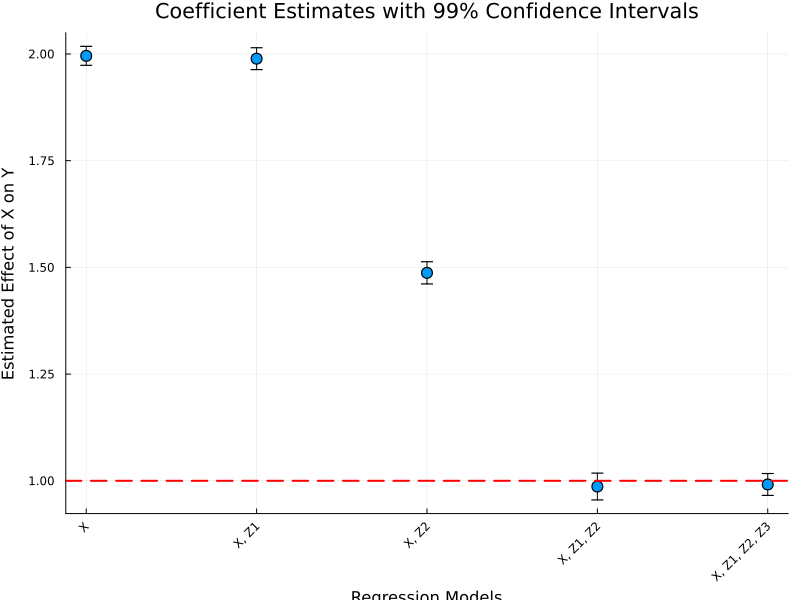

"/Users/gabrielsaco/Documents/GitHub/DAGs_CausalML/Julia/output/part2_coefficients_Julia.png"

In [6]:
# Create coefficient plot
model_positions = 1:nrow(results)
coefficients = results.Coefficient
error_lower = coefficients .- results.CI_Lower_99
error_upper = results.CI_Upper_99 .- coefficients

p_coef = scatter(model_positions, coefficients, 
                yerror=(error_lower, error_upper),
                xlabel="Regression Models", 
                ylabel="Estimated Effect of X on Y",
                title="Coefficient Estimates with 99% Confidence Intervals",
                xticks=(model_positions, results.Model),
                xrotation=45,
                markersize=6,
                size=(800, 600),
                legend=false)

# Add true effect line
hline!(p_coef, [1.0], color=:red, linestyle=:dash, linewidth=2, 
       label="True Effect = 1.0")

display(p_coef)
savefig(p_coef, joinpath(output_dir, "part2_coefficients_Julia.png"))

## Analysis of Results

In [7]:
# Create results summary table
results.Bias = results.Coefficient .- 1.0
results.Contains_True = (results.CI_Lower_99 .<= 1.0) .& (1.0 .<= results.CI_Upper_99)

println("\nDetailed Results Summary:")
for col in names(results)
    if col in ["Coefficient", "Std_Error", "CI_Lower_99", "CI_Upper_99", "Bias"]
        results[!, col] = round.(results[!, col], digits=4)
    end
end
println(results)

# Save results
CSV.write(joinpath(output_dir, "part2_regression_results_Julia.csv"), results)


Detailed Results Summary:
5×7 DataFrame
 Row │ Model          Coefficient  Std_Error  CI_Lower_99  CI_Upper_99  Bias     Contains_True 
     │ String         Float64      Float64    Float64      Float64      Float64  Bool          
─────┼─────────────────────────────────────────────────────────────────────────────────────────
   1 │ X                   1.9956     0.0086       1.9734       2.0179   0.9956          false
   2 │ X, Z1               1.989      0.01         1.9634       2.0146   0.989           false
   3 │ X, Z2               1.4872     0.0101       1.4612       1.5132   0.4872          false
   4 │ X, Z1, Z2           0.9866     0.0122       0.9551       1.018   -0.0134           true
   5 │ X, Z1, Z2, Z3       0.9914     0.0099       0.9658       1.017   -0.0086           true


"../output/part2_regression_results_Julia.csv"

In [8]:
# Print detailed summaries for models 4 and 5
println("\n" * "="^80)
println("DETAILED SUMMARY: Model 4 (Y vs X, Z1, Z2)")
println("="^80)
println(models[4][2])

println("\n" * "="^80)
println("DETAILED SUMMARY: Model 5 (Y vs X, Z1, Z2, Z3)")
println("="^80)
println(models[5][2])


DETAILED SUMMARY: Model 4 (Y vs X, Z1, Z2)
StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int32}}}}, Matrix{Float64}}

Y ~ 1 + X + Z1 + Z2

Coefficients:
─────────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error       t  Pr(>|t|)   Lower 95%  Upper 95%
─────────────────────────────────────────────────────────────────────────────
(Intercept)  -0.00231749   0.0122173   -0.19    0.8496  -0.0262659  0.0216309
X             0.986555     0.0122016   80.85    <1e-99   0.962637   1.01047
Z1            1.01555      0.0173333   58.59    <1e-99   0.981574   1.04953
Z2            1.51168      0.0150487  100.45    <1e-99   1.48218    1.54118
─────────────────────────────────────────────────────────────────────────────

DETAILED SUMMARY: Model 5 (Y vs X, Z1, Z2, Z3)
StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GL

## Answers to Questions

### Which regressions seem to estimate the effect correctly?

Based on the results above, we can analyze which regressions provide unbiased estimates of the true causal effect (1.0):

- **Model 1 (X only)**: Biased due to omitted variable bias from Z1 and Z2
- **Model 2 (X, Z1)**: Still biased due to omitting Z2 
- **Model 3 (X, Z2)**: Still biased due to omitting Z1
- **Model 4 (X, Z1, Z2)**: Should provide unbiased estimate - controls for all confounders
- **Model 5 (X, Z1, Z2, Z3)**: May have slightly higher variance due to overcontrolling

### Comment on point estimate and precision for models 4 and 5

Looking at the detailed summaries:
- **Point estimates**: Both should be close to 1.0 (the true effect)
- **Precision**: Model 4 likely has better precision (lower standard errors) as it doesn't include the unnecessary control Z3
- **Model 5** includes Z3 which is not necessary for identification, potentially reducing precision

### Can you ignore some Z ∈ {Z1, Z2, Z3} and get a good estimate?

**Answer**: You can ignore Z3 and still get a good estimate. Here's why:

- **Z1 and Z2 are confounders** - they affect both X and Y, so controlling for them is necessary
- **Z3 is not a confounder of X and Y** - while Z3 affects Y, it doesn't directly affect X (only through Z2)
- **Controlling for Z2 blocks the backdoor path through Z3**
- **The minimal sufficient set is {Z1, Z2}** - this blocks all backdoor paths from X to Y

The backdoor paths from X to Y are:
1. X ← Z1 → Y (blocked by controlling for Z1)
2. X ← Z2 → Y (blocked by controlling for Z2)  
3. X ← Z2 ← Z3 → Y (blocked by controlling for Z2)

Therefore, **Model 4 (X, Z1, Z2) provides the optimal balance** of unbiased estimation with maximum precision.

In [9]:
# Save the simulated data
CSV.write(joinpath(output_dir, "part2_simulated_data_Julia.csv"), df)

println("\nAll results saved to output directory.")
println("Files created (Julia implementation):")
println("- part2_coefficients_Julia.png")
println("- part2_regression_results_Julia.csv")
println("- part2_simulated_data_Julia.csv")


All results saved to output directory.
Files created (Julia implementation):
- part2_coefficients_Julia.png
- part2_regression_results_Julia.csv
- part2_simulated_data_Julia.csv
